# 📈 Sales Prediction Using Python
Predict **Sales** from advertising spend on **TV, Radio, Newspaper** using Linear Regression (baseline), Polynomial Regression and Random Forest.

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_theme(style='whitegrid', palette='magma')

## 1. Load data & EDA
Classic *Advertising.csv* (Kaggle / ISLR). Spend is in thousands of dollars.

In [5]:
df = pd.read_csv('Advertising.csv', index_col=0)
print(df.shape); df.head()

(200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [6]:
print('Null values:\n', df.isnull().sum())
df.describe()

Null values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


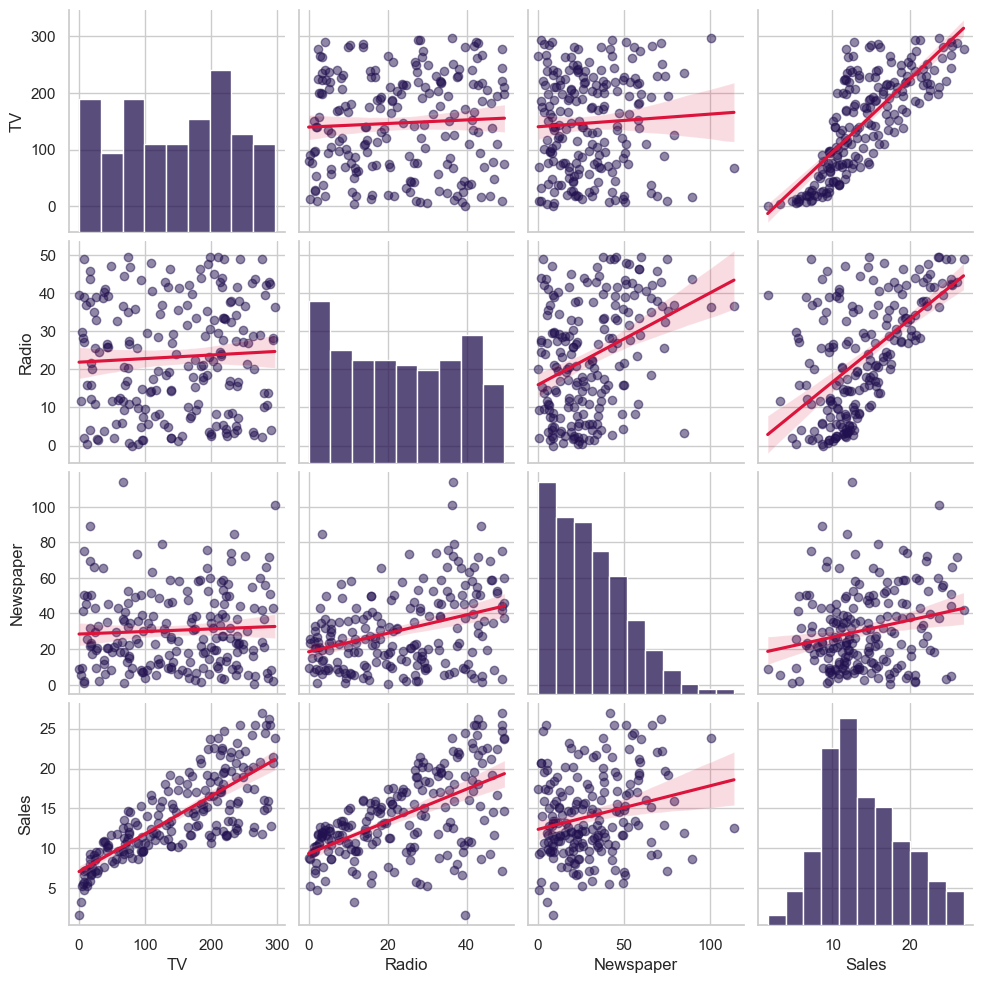

In [7]:
sns.pairplot(df, kind='reg', plot_kws={'line_kws':{'color':'crimson'},'scatter_kws':{'alpha':.5}})
plt.show()

## 2. Sales vs each channel

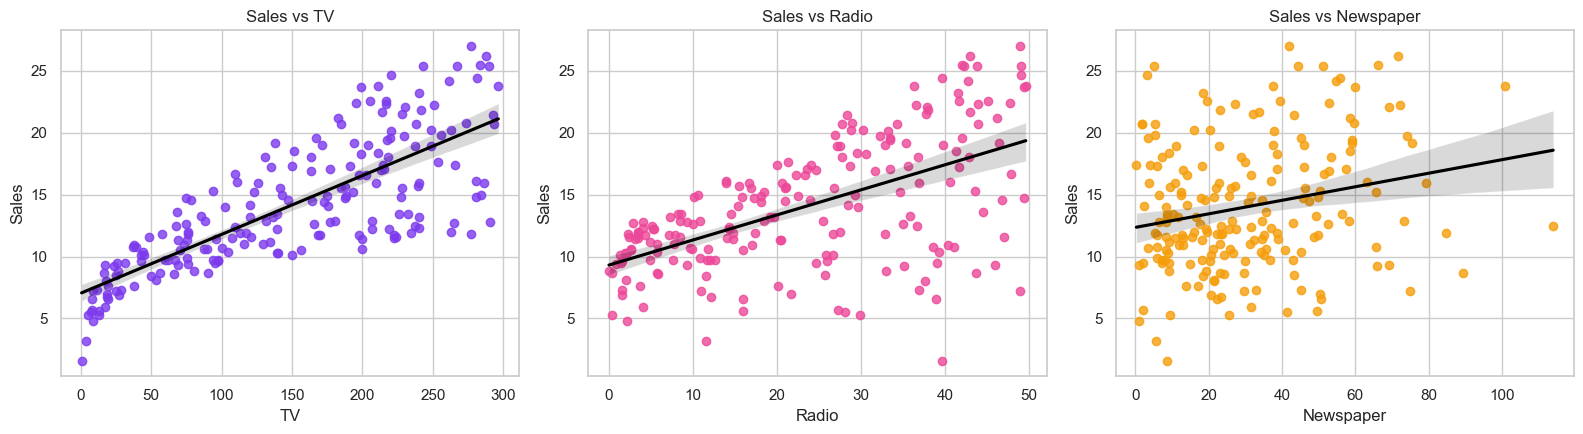

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, col, c in zip(ax, ['TV','Radio','Newspaper'], ['#7c3aed','#ec4899','#f59e0b']):
    sns.regplot(x=col, y='Sales', data=df, ax=a, color=c, line_kws={'color':'k'})
    a.set_title(f'Sales vs {col}')
plt.tight_layout(); plt.show()

## 3. Correlation heatmap

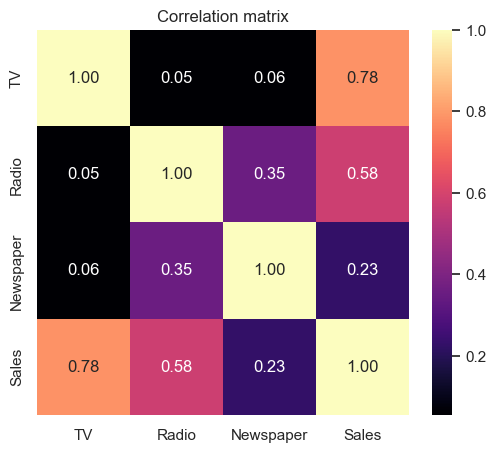

In [9]:
plt.figure(figsize=(6,5)); sns.heatmap(df.corr(), annot=True, cmap='magma', fmt='.2f'); plt.title('Correlation matrix'); plt.show()

## 4. Train / test split (80/20)

In [10]:
X, y = df[['TV','Radio','Newspaper']], df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Train models
Linear Regression = baseline.

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Polynomial (deg 2)': make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression()),
    'Random Forest': RandomForestRegressor(n_estimators=300, random_state=42),
}
rows, preds = [], {}
for name, m in models.items():
    m.fit(X_train, y_train); p = m.predict(X_test); preds[name] = p
    rows.append([name, mean_absolute_error(y_test,p), np.sqrt(mean_squared_error(y_test,p)), r2_score(y_test,p)])
results = pd.DataFrame(rows, columns=['Model','MAE','RMSE','R2']).set_index('Model').round(3)
results

,MAE,RMSE,R2
Model,,,
Linear Regression,1.461,1.782,0.899
Polynomial (deg 2),0.526,0.643,0.987
Random Forest,0.613,0.740,0.983


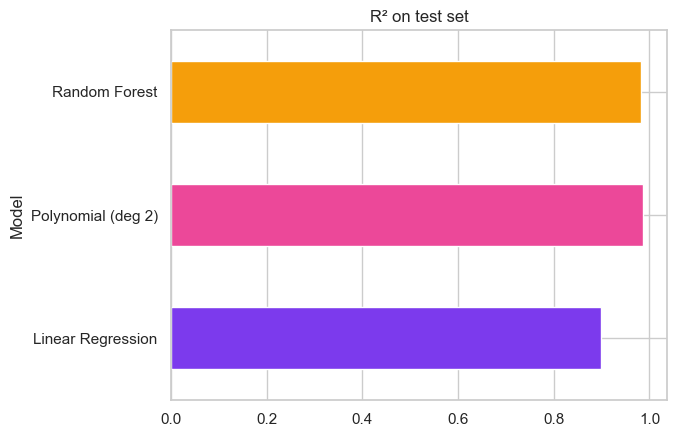

In [12]:
results['R2'].plot(kind='barh', color=['#7c3aed','#ec4899','#f59e0b'], title='R² on test set'); plt.show()

## 6. Residual analysis (best model)

Best model: Polynomial (deg 2)


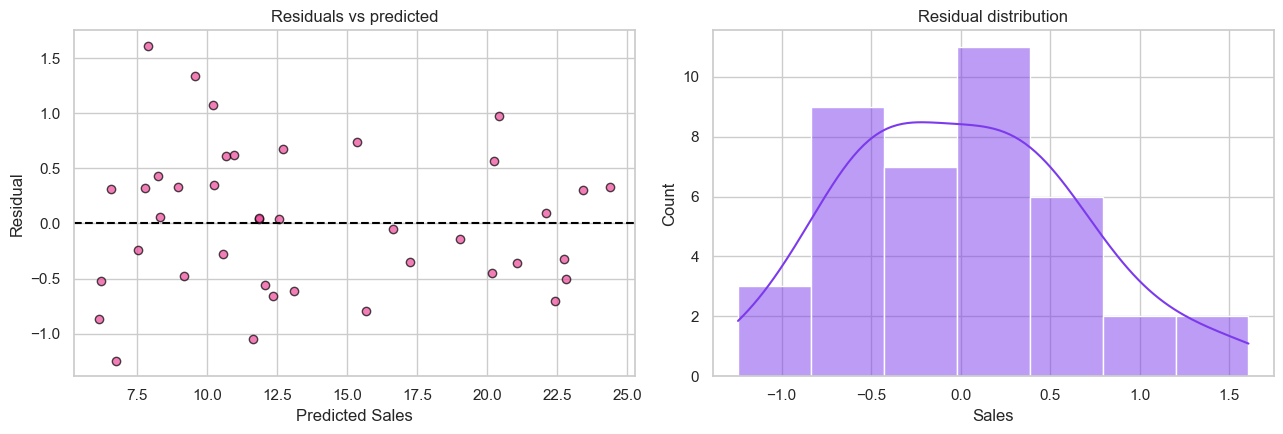

In [13]:
best = results['R2'].idxmax(); print('Best model:', best)
res = y_test - preds[best]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(preds[best], res, c='#ec4899', alpha=.7, edgecolor='k'); ax[0].axhline(0, color='k', ls='--')
ax[0].set(xlabel='Predicted Sales', ylabel='Residual', title='Residuals vs predicted')
sns.histplot(res, kde=True, ax=ax[1], color='#7c3aed'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()

Residuals scatter around zero with no strong funnel or curve, so errors are mostly random. Check the plot for any leftover pattern.

## 7. Interpretation: which channel matters most?

In [14]:
lr = models['Linear Regression']; rf = models['Random Forest']
imp = pd.DataFrame({'LR coefficient (per $1k)': lr.coef_, 'LR standardised |coef|': np.abs(lr.coef_*X_train.std().values),
                    'RF importance': rf.feature_importances_}, index=X.columns).round(4)
print('Intercept:', round(lr.intercept_,3)); imp

Intercept: 2.979


,LR coefficient (per $1k),LR standardised |coef|,RF importance
TV,0.0447,3.7760,0.6254
Radio,0.1892,2.8011,0.3617
Newspaper,0.0028,0.0562,0.0128


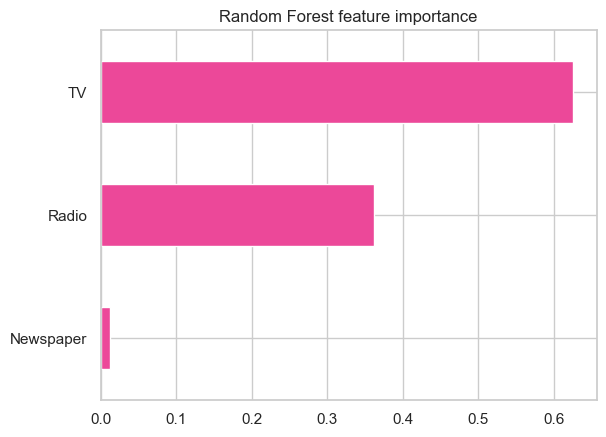

In [15]:
imp['RF importance'].sort_values().plot(kind='barh', color='#ec4899', title='Random Forest feature importance'); plt.show()

**Conclusion:** TV drives sales most (highest importance and standardised effect). Radio gives the most sales *per dollar* (largest raw coefficient). Newspaper has near-zero effect once TV and Radio are accounted for.